In [52]:
import pandas as pd
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv('../data/metadata.csv')

print(f'Data Loaded: {df.shape[0]} rows, {df.shape[1]} cols')

# Only relevent data

df = df.loc[:, ['patient_id', 'img_id', 'diagnostic']]
df.head(3)

Data Loaded: 2298 rows, 26 cols


,patient_id,img_id,diagnostic
0,PAT_1516,PAT_1516_1765_530.png,NEV
1,PAT_46,PAT_46_881_939.png,BCC
2,PAT_1545,PAT_1545_1867_547.png,ACK


In [54]:
# Function to filter valid mask
from skimage import measure

def valid_mask(filename:str) -> bool:
    '''Identifies valid masks given some constraints.'''
    
    valid = False
    path_mask = '../data/masks/' + filename.replace('.png', '_mask.png')

    try:
        mask = plt.imread(path_mask)
    except FileNotFoundError:
        return np.nan, np.nan

    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)
    sorted_props = sorted(props, key = lambda r: r.area, reverse = True)
    condition = False
    
    if len(props) > 1:
        condition = sorted_props[0].area >= 3*sorted_props[1].area

    if len(props) == 1 or condition:
        valid = True
    
    return valid, len(props)

data = df['img_id'].apply(valid_mask)
df['Valid_mask'] = [x[0] for x in data]
df['number_of_regions'] = [x[1] for x in data]

In [55]:
df = pd.read_csv('../data/new_metadata.csv', index_col=0)

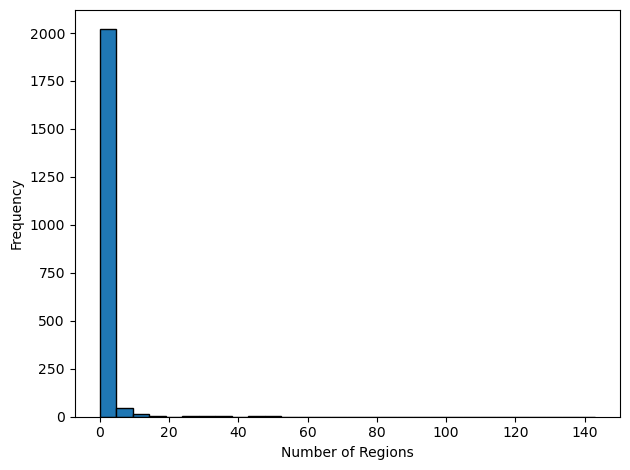

In [56]:
# ======================================
# SPOT OUTLIERS
# ======================================

# VISUAL INSPECTION 

fig = plt.figure()
data = df.number_of_regions
plt.hist(data, bins=30, edgecolor='black')
plt.xlabel('Number of Regions')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [57]:
def outliers(data):
    '''returns outliers of the given data'''
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + IQR

    return data[data > upper_limit]

In [58]:
# Modified mask for more than one regions.
from skimage import measure

def modified_mask(mask):
    
    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)

    # Find region with maximum area
    largest_region = max(props, key = lambda r: r.area)

    # Extract its label
    largest_label = largest_region.label

    # Create mask for that region
    largest_mask = (labeled == largest_label).astype(bool)

    aux_mask = binary_mask.copy()
    aux_mask[largest_mask] = False

    return np.logical_xor(binary_mask, aux_mask)


In [59]:
def show_img_mask(filename):
    '''Displays the image with its corresponding mask'''
    
    path_img = '../data/imgs/' + filename
    path_mask = '../data/masks/' + filename.replace('.png', '_mask.png')
    
    try:
        img, mask = plt.imread(path_img), plt.imread(path_mask)
    except FileNotFoundError:
        return

    before_mask = (mask > 0.5).astype(bool)
    after_mask = modified_mask(before_mask)

    fig, ax = plt.subplots(1,3, figsize = (10,8))

    # plot image
    ax[0].imshow(img)
    ax[0].axis('off')
    ax[0].set_title(filename)

    # plot before mask
    ax[1].imshow(before_mask, cmap='grey')
    ax[1].axis('off')
    ax[1].set_title('Before')

    # plot after mask
    ax[2].imshow(after_mask, cmap='grey')
    ax[2].axis('off')
    ax[2].set_title("After")

    plt.tight_layout()
    plt.show()

In [60]:
df.head()

,patient_id,img_id,diagnostic,Valid_mask,number_of_regions
0,PAT_1516,PAT_1516_1765_530.png,NEV,True,1
1,PAT_46,PAT_46_881_939.png,BCC,True,1
2,PAT_1545,PAT_1545_1867_547.png,ACK,True,1
3,PAT_1989,PAT_1989_4061_934.png,ACK,True,1
4,PAT_684,PAT_684_1302_588.png,BCC,True,1


In [61]:
df[(df.Valid_mask == False) & (df.number_of_regions > 2)].sort_values(by = 'number_of_regions', ascending = False)

,patient_id,img_id,diagnostic,Valid_mask,number_of_regions
1398,PAT_87,PAT_87_133_810.png,SEK,False,28
603,PAT_1491,PAT_1491_1703_637.png,ACK,False,26
1357,PAT_738,PAT_738_1552_843.png,SEK,False,17
1866,PAT_93,PAT_93_361_51.png,SEK,False,16
443,PAT_999,PAT_999_20_540.png,ACK,False,16
...,...,...,...,...,...
1807,PAT_1274,PAT_1274_954_677.png,ACK,False,3
1851,PAT_1216,PAT_1216_760_593.png,ACK,False,3
1914,PAT_1855,PAT_1855_3641_327.png,ACK,False,3
1918,PAT_91,PAT_91_140_664.png,ACK,False,3


In [62]:
df = pd.read_csv('../data/new_metadata.csv', index_col=0)
df = df[df['Valid_mask'] == True]
df.shape


(1945, 5)

In [63]:
feature_df = df.loc[:,['patient_id', 'img_id', 'diagnostic']]
features = ['feature_A', 'feature_B', 'feature_C', 'feature_D']
feature_df['mask_id'] = df['img_id'].str.replace('.png', '_mask.png')

for f in features:
    feature_df[f] = 0

    
feature_df

,patient_id,img_id,diagnostic,mask_id,feature_A,feature_B,feature_C,feature_D
0,PAT_1516,PAT_1516_1765_530.png,NEV,PAT_1516_1765_530_mask.png,0,0,0,0
1,PAT_46,PAT_46_881_939.png,BCC,PAT_46_881_939_mask.png,0,0,0,0
2,PAT_1545,PAT_1545_1867_547.png,ACK,PAT_1545_1867_547_mask.png,0,0,0,0
3,PAT_1989,PAT_1989_4061_934.png,ACK,PAT_1989_4061_934_mask.png,0,0,0,0
4,PAT_684,PAT_684_1302_588.png,BCC,PAT_684_1302_588_mask.png,0,0,0,0
...,...,...,...,...,...,...,...,...
2098,PAT_386,PAT_386_785_536.png,ACK,PAT_386_785_536_mask.png,0,0,0,0
2099,PAT_273,PAT_273_421_905.png,BCC,PAT_273_421_905_mask.png,0,0,0,0
2100,PAT_491,PAT_491_934_46.png,SCC,PAT_491_934_46_mask.png,0,0,0,0
2101,PAT_46,PAT_46_880_140.png,BCC,PAT_46_880_140_mask.png,0,0,0,0


In [64]:
mask_path = '../data/masks/' + feature_df['img_id'][0].replace('.png', '_mask.png')


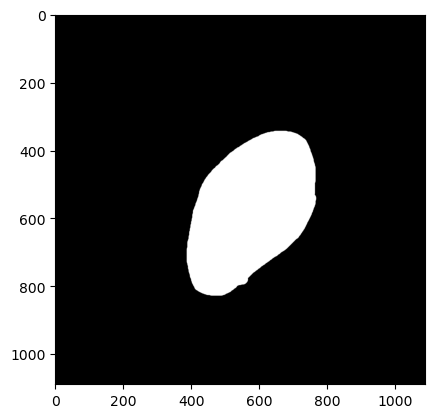

In [65]:
mask = plt.imread(mask_path)
plt.imshow(mask, cmap='grey')


In [66]:
feature_df

,patient_id,img_id,diagnostic,mask_id,feature_A,feature_B,feature_C,feature_D
0,PAT_1516,PAT_1516_1765_530.png,NEV,PAT_1516_1765_530_mask.png,0,0,0,0
1,PAT_46,PAT_46_881_939.png,BCC,PAT_46_881_939_mask.png,0,0,0,0
2,PAT_1545,PAT_1545_1867_547.png,ACK,PAT_1545_1867_547_mask.png,0,0,0,0
3,PAT_1989,PAT_1989_4061_934.png,ACK,PAT_1989_4061_934_mask.png,0,0,0,0
4,PAT_684,PAT_684_1302_588.png,BCC,PAT_684_1302_588_mask.png,0,0,0,0
...,...,...,...,...,...,...,...,...
2098,PAT_386,PAT_386_785_536.png,ACK,PAT_386_785_536_mask.png,0,0,0,0
2099,PAT_273,PAT_273_421_905.png,BCC,PAT_273_421_905_mask.png,0,0,0,0
2100,PAT_491,PAT_491_934_46.png,SCC,PAT_491_934_46_mask.png,0,0,0,0
2101,PAT_46,PAT_46_880_140.png,BCC,PAT_46_880_140_mask.png,0,0,0,0


In [67]:
feature_df['img_id'][0]

'PAT_1516_1765_530.png'

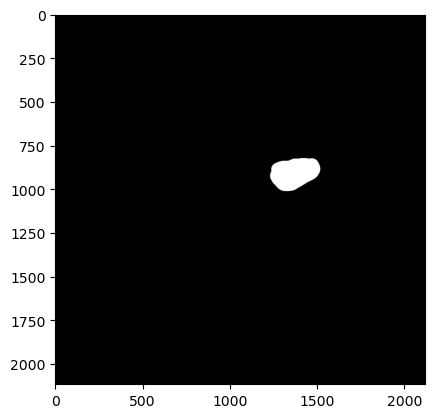

In [68]:
mask = plt.imread('../data/masks/PAT_1989_4061_934_mask.png')
plt.imshow(mask, cmap='grey');

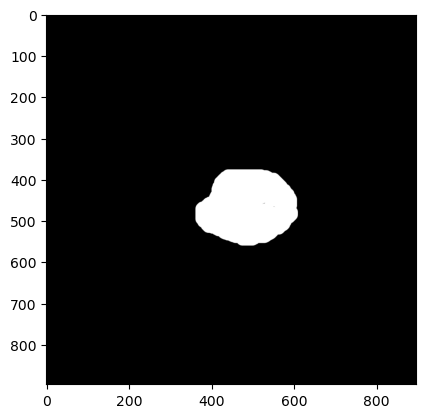

In [69]:
mask = plt.imread('../data/masks/PAT_684_1302_588_mask.png')
plt.imshow(mask, cmap='grey');

In [70]:
data = pd.read_csv('../data/features.csv')

In [71]:
data

,img_id,hsv_mean_h,hsv_mean_s,hsv_mean_v,hsv_std_h,hsv_std_s,hsv_std_v,sp_hsv_std_h,sp_hsv_std_s,sp_hsv_std_v,rel_hsv_diff_h,rel_hsv_diff_s,rel_hsv_diff_v,symmetry,border,diameter,processing_status,error_message
0,PAT_1516_1765_530.png,0.596812,0.721593,0.562349,0.006291,0.074704,0.049599,0.006266,0.081665,0.049079,0.009937,0.188500,0.083608,0.738506,0.776982,0.859504,success,NaN
1,PAT_46_881_939.png,0.731211,0.200618,0.668742,0.062351,0.131785,0.043039,0.056869,0.124764,0.038754,0.065885,0.048277,0.017007,0.734336,0.579152,0.960274,success,NaN
2,PAT_1545_1867_547.png,0.674872,0.495146,0.606443,0.009140,0.058582,0.069610,0.007575,0.051897,0.067342,0.012132,0.077684,0.092984,0.680112,0.625163,1.000000,success,NaN
3,PAT_1989_4061_934.png,0.646455,0.214990,0.608748,0.027248,0.064702,0.029728,0.026081,0.063807,0.030374,0.034895,0.020770,0.000674,0.690998,0.779322,0.979094,success,NaN
4,PAT_684_1302_588.png,0.669910,0.397585,0.526509,0.015145,0.059756,0.038256,0.015093,0.059827,0.034487,0.027133,0.050405,0.010770,0.881281,0.832370,1.000000,success,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1940,PAT_386_785_536.png,0.571499,0.362363,0.515640,0.037066,0.107024,0.142071,0.032826,0.087493,0.128353,0.052181,0.068528,0.135419,0.765386,0.813212,0.948387,success,NaN
1941,PAT_273_421_905.png,0.650089,0.626976,0.649245,0.010241,0.072418,0.073848,0.008894,0.057572,0.059647,0.006087,0.001372,0.005332,0.895364,0.862230,1.000000,success,NaN
1942,PAT_491_934_46.png,0.632516,0.387129,0.773343,0.014211,0.082124,0.056153,0.012397,0.074813,0.048381,0.012684,0.012868,0.023426,0.920479,0.874997,1.000000,success,NaN
1943,PAT_46_880_140.png,0.706472,0.367574,0.622942,0.035992,0.077307,0.034082,0.024676,0.070764,0.028704,0.047487,0.066641,0.019838,0.788334,0.773051,0.986352,success,NaN


In [72]:
data.sort_values(by = 'diameter', ascending = False).head(10)

,img_id,hsv_mean_h,hsv_mean_s,hsv_mean_v,hsv_std_h,hsv_std_s,hsv_std_v,sp_hsv_std_h,sp_hsv_std_s,sp_hsv_std_v,rel_hsv_diff_h,rel_hsv_diff_s,rel_hsv_diff_v,symmetry,border,diameter,processing_status,error_message
22,PAT_106_159_325.png,0.655356,0.614844,0.534985,0.014696,0.121307,0.045192,0.012724,0.111141,0.038624,0.000461,0.060702,0.026819,0.804207,0.698381,1.0,success,NaN
1944,PAT_326_690_823.png,0.662955,0.382170,0.700245,0.020406,0.105157,0.032953,0.021432,0.105454,0.031144,0.022301,0.096489,0.019026,0.898760,0.849816,1.0,success,NaN
19,PAT_875_1668_588.png,0.702101,0.387945,0.500728,0.022913,0.093472,0.040725,0.021070,0.090091,0.039498,0.014795,0.048195,0.011743,0.929808,0.878091,1.0,success,NaN
1942,PAT_491_934_46.png,0.632516,0.387129,0.773343,0.014211,0.082124,0.056153,0.012397,0.074813,0.048381,0.012684,0.012868,0.023426,0.920479,0.874997,1.0,success,NaN
2,PAT_1545_1867_547.png,0.674872,0.495146,0.606443,0.009140,0.058582,0.069610,0.007575,0.051897,0.067342,0.012132,0.077684,0.092984,0.680112,0.625163,1.0,success,NaN
17,PAT_821_1547_77.png,0.638266,0.343651,0.759477,0.008465,0.039229,0.024319,0.007488,0.038006,0.020517,0.006779,0.001275,0.004340,0.712142,0.659271,1.0,success,NaN
4,PAT_684_1302_588.png,0.669910,0.397585,0.526509,0.015145,0.059756,0.038256,0.015093,0.059827,0.034487,0.027133,0.050405,0.010770,0.881281,0.832370,1.0,success,NaN
5,PAT_1549_1882_230.png,0.555939,0.157944,0.485180,0.063136,0.074730,0.109384,0.045444,0.058207,0.077140,0.039465,0.010903,0.063034,0.906016,0.857122,1.0,success,NaN
6,PAT_778_1471_835.png,0.606538,0.420581,0.825540,0.007945,0.047344,0.046940,0.006949,0.041541,0.035784,0.009582,0.076159,0.044358,0.840749,0.842032,1.0,success,NaN
16,PAT_759_1538_566.png,0.651160,0.524065,0.711548,0.006714,0.095262,0.036917,0.005813,0.092956,0.034673,0.007911,0.009306,0.015251,0.888971,0.860683,1.0,success,NaN


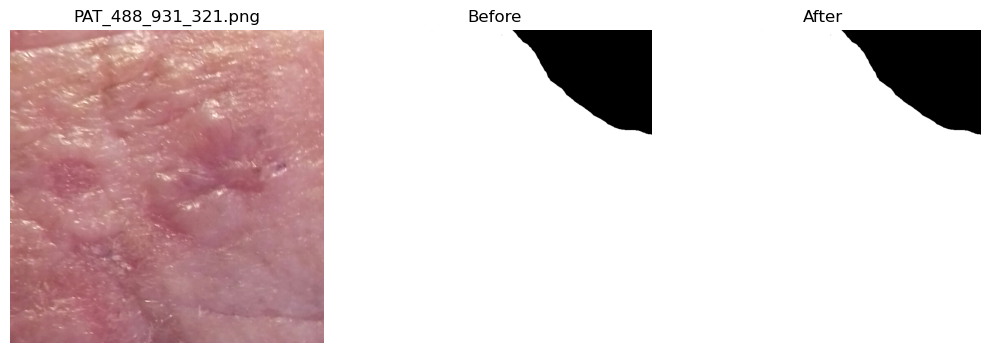

In [73]:
show_img_mask('PAT_488_931_321.png')

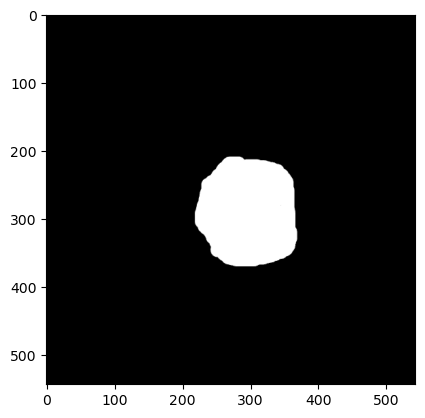

In [74]:
mask = plt.imread('../data/masks/PAT_326_690_823_mask.png')
plt.imshow(mask, cmap='grey');

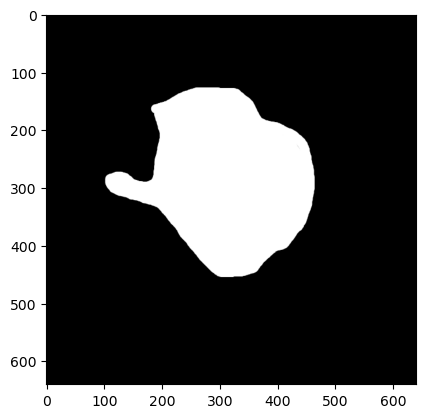

In [75]:
mask = plt.imread('../data/masks/PAT_1545_1867_547_mask.png')
plt.imshow(mask, cmap='grey');

In [76]:
data.symmetry.median()

0.8023252380656146

In [77]:
import seaborn as sns

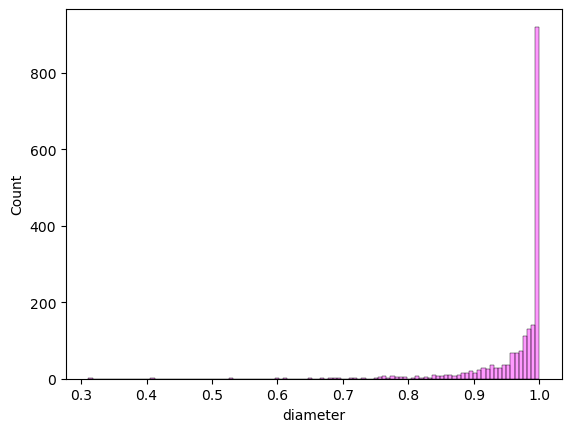

In [78]:
sns.histplot(data = data, x = 'diameter', kde = False, color = 'magenta', alpha = 0.4);